# Feature Importance — SHAP by Taxonomy Category

SHAP values (TreeExplainer) for the selected LightGBM configuration trained on the primary group split
(seed 42, model seed 42), computed on the test partition. Mean |SHAP| ranks features overall and within
each taxonomy category (IxL, IxI, IxE). SHAP splits credit among correlated features consistently,
unlike gain-based importance; proposed in place of the gain-based importance tables (an author decision).

In [1]:
import warnings
import numpy as np
import pandas as pd
import sybil_pipeline as sp
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
DATA_DIR, SEED = './data', sp.SEED
import shap
import matplotlib.pyplot as plt
_, LGBM_SELECTED = sp.load_selected_params()
df, _, _ = sp.build_master_df(DATA_DIR, verbose=False)
S = sp.make_splits(df, sp.FEATS, method='group', seed=SEED)
m = sp.fit_lgbm(S, LGBM_SELECTED, seeds=(SEED,))['models'][0]   # same code as 04_lightgbm_sybil, one seed
X = S['X_test']
sv = shap.TreeExplainer(m).shap_values(X)
sv = sv[1] if isinstance(sv, list) else sv
cat = df.loc[S['idx_test'], 'category'].to_numpy()
imp = pd.DataFrame({'All': np.abs(sv).mean(0)}, index=X.columns)
for c in ['IxL', 'IxI', 'IxE']:
    imp[c] = np.abs(sv[cat == c]).mean(0)
fam = {f: k for k, v in sp.FEATURE_FAMILIES.items() for f in v}
imp['family'] = imp.index.map(fam)
imp = imp.sort_values('All', ascending=False)
print(imp.head(25).round(4).to_string())
print('\nMean |SHAP| by family:'); print(imp.groupby('family')[['All', 'IxL', 'IxI', 'IxE']].sum().round(4).to_string())

  LightGBM seed=42  rounds=315  52.5s


                                        All     IxL     IxI     IxE                  family
n_l0_source_contracts                0.9039  0.8359  0.9161  1.1221  LayerZero transactions
l0_tx_time_span                      0.9005  0.8650  0.8832  1.0221  LayerZero transactions
earliest_l0_tx_time                  0.5431  0.5504  0.4674  0.5459  LayerZero transactions
l0_avg_stargate_swap                 0.4743  0.4979  0.3979  0.4249  LayerZero transactions
num_transactions_in                  0.4569  0.4546  0.3896  0.4882   Ethereum transactions
max_tx_value_out                     0.4256  0.4489  0.3934  0.3613   Ethereum transactions
n_l0_source_chains                   0.4162  0.3849  0.4073  0.5211  LayerZero transactions
latest_l0_tx_time                    0.3503  0.3545  0.3295  0.3440  LayerZero transactions
earliest_tx_block_in                 0.3490  0.3576  0.3280  0.3284   Ethereum transactions
tx_value_per_block_out               0.2590  0.2678  0.2320  0.2394   Ethereum t

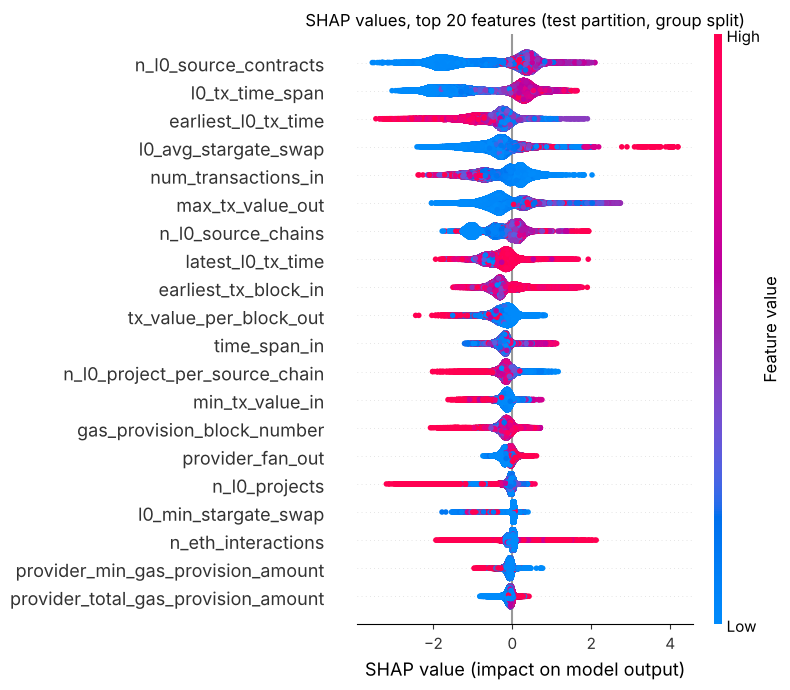

In [2]:
top = imp.head(20).index
fig, ax = plt.subplots(figsize=(8, 7))
plt.sca(ax)
shap.summary_plot(sv[:, [list(X.columns).index(f) for f in top]], X[top], show=False, plot_size=None)
plt.title('SHAP values, top 20 features (test partition, group split)')
plt.tight_layout(); plt.show()

In [3]:
sp.save_results([], '09_shap_importance', extra=dict(
    mean_abs_shap=imp.reset_index().rename(columns={'index': 'feature'}).to_dict('records'), params=LGBM_SELECTED))

Saved results/09_shap_importance.json
